In [2]:
# === CELL 1: FIXING THE COLUMN NAMES ===
import pandas as pd
from fairlearn.datasets import fetch_bank_marketing

print("Fetching Bank Marketing dataset...")
bank_data = fetch_bank_marketing(as_frame=True)

X = bank_data.data
y = bank_data.target

# Print out the exact names of all columns to find 'age'
print("\n--- Exact Column Names inside X ---")
print(list(X.columns))

print("\n--- First 2 rows of the features to look at them ---")
print(X.head(2))

Fetching Bank Marketing dataset...

--- Exact Column Names inside X ---
['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16']

--- First 2 rows of the features to look at them ---
   V1          V2       V3         V4  V5    V6   V7  V8       V9  V10  V11  \
0  58  management  married   tertiary  no  2143  yes  no  unknown    5  may   
1  44  technician   single  secondary  no    29  yes  no  unknown    5  may   

   V12  V13  V14  V15      V16  
0  261    1   -1    0  unknown  
1  151    1   -1    0  unknown  


In [3]:
# === CELL 1: SUMMARY OF THE AGE COLUMN ===
import pandas as pd
from fairlearn.datasets import fetch_bank_marketing

print("Fetching Bank Marketing dataset...")
bank_data = fetch_bank_marketing(as_frame=True)

X = bank_data.data
y = bank_data.target

# Rename V1 to 'age' so it's simple to read
X = X.rename(columns={'V1': 'age'})

print("\n--- Summary of the 'age' Column ---")
print(X['age'].describe())

print("\n--- Sample of the first 5 ages ---")
print(X['age'].head())

Fetching Bank Marketing dataset...

--- Summary of the 'age' Column ---
count    45211.000000
mean        40.936210
std         10.618762
min         18.000000
25%         33.000000
50%         39.000000
75%         48.000000
max         95.000000
Name: age, dtype: float64

--- Sample of the first 5 ages ---
0    58
1    44
2    33
3    47
4    33
Name: age, dtype: int64


In [15]:
# === CELL 2: DATA PREPROCESSING FOR 3 ATTRIBUTES (UPDATED) ===
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

print("Starting Bank Marketing preprocessing for 3 attributes...")

# 1. Prepare Features safely
X_clean = X.rename(columns={'V1': 'age', 'V3': 'marital', 'V4': 'education'})

# Create Attribute 1: Age Group (1 if >= 40, else 0)
X_clean['sensitive_age_group'] = np.where(X_clean['age'] >= 40, 1, 0)

# Create Attribute 2: Marital Status (1 if married, else 0)
X_clean['sensitive_marital'] = np.where(X_clean['marital'] == 'married', 1, 0)

# Create Attribute 3: Education Level (1 if tertiary, else 0)
X_clean['sensitive_education'] = np.where(X_clean['education'] == 'tertiary', 1, 0)

# Drop the original columns so models don't use them directly
X_features = X_clean.drop(columns=['age', 'marital', 'education'])

# 2. Fix target variable y
y_values = np.array(y)
y_clean = np.where((y_values == 2) | (y_values == '2') | (y_values == 'yes'), 1, 0)

# 3. Convert remaining text columns into numbers (One-Hot Encoding)
X_encoded = pd.get_dummies(X_features, drop_first=True)

# 4. Split everything into Train and Test sets safely
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_clean, test_size=0.2, random_state=42, stratify=y_clean
)

print("\n🎉 Preprocessing complete! 3 Protected attributes are mapped.")
print(f"Training samples: {X_train.shape[0]} | Testing samples: {X_test.shape[0]}")

Starting Bank Marketing preprocessing for 3 attributes...

🎉 Preprocessing complete! 3 Protected attributes are mapped.
Training samples: 36168 | Testing samples: 9043


In [16]:
# === CELL 3: UTILITY PERFORMANCE ENGINE ===
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def _get_model_performance(y_true, y_pred):
    """Calculates all standard performance metrics matching your pipeline format."""
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_pred) if len(np.unique(y_true)) > 1 else np.nan
    }

print("Performance evaluation engine established successfully!")

Performance evaluation engine established successfully!


In [17]:
# === CELL 4: STRATIFIED BASELINE MODEL TRAINING ===
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

print("Initializing your 3 core models...")

# Define the models matching your original loop parameters
MODELS = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    "XGB": XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42, eval_metric='logloss')
}

# Dictionary to hold onto trained baseline models for our fairness audits next
trained_base_models = {}
baseline_predictions = {}

print("\n--- Training Models on Bank Marketing Dataset ---")
for model_name, model_obj in MODELS.items():
    print(f"Training Base Model: {model_name}...")
    
    # Clone and fit the model on our training arrays
    model = clone(model_obj)
    model.fit(X_train, y_train)
    
    # Generate test predictions
    y_pred = model.predict(X_test)
    
    # Save the models and predictions for the next cells
    trained_base_models[model_name] = model
    baseline_predictions[model_name] = y_pred
    
    # Print out a quick snapshot of how well they did right away!
    perf = _get_model_performance(y_test, y_pred)
    print(f"   ↳ Result -> Accuracy: {perf['accuracy']:.4f} | F1-Score: {perf['f1']:.4f} | Recall: {perf['recall']:.4f}")

print("\n🎉 Step 1 complete! Baseline models are fully trained and stored.")

Initializing your 3 core models...

--- Training Models on Bank Marketing Dataset ---
Training Base Model: LogisticRegression...
   ↳ Result -> Accuracy: 0.8389 | F1-Score: 0.5420 | Recall: 0.8147
Training Base Model: RandomForest...
   ↳ Result -> Accuracy: 0.9055 | F1-Score: 0.4639 | Recall: 0.3497
Training Base Model: XGB...
   ↳ Result -> Accuracy: 0.9079 | F1-Score: 0.5254 | Recall: 0.4357

🎉 Step 1 complete! Baseline models are fully trained and stored.


In [18]:
# === CELL 5: MATHEMATICALLY CORRECT FAIRNESS ENGINE ===
from sklearn.metrics import confusion_matrix

def run_fairness_eval(y_true, y_pred, sensitive_col):
    """Calculates true difference-based metrics matching Fairlearn strict definitions."""
    df_eval = pd.DataFrame({'y_true': y_true, 'y_pred': y_pred, 'group': sensitive_col})
    
    # 1. Demographic Parity
    dp_rates = df_eval.groupby('group')['y_pred'].mean()
    demographic_parity_difference = dp_rates.max() - dp_rates.min()
    
    tpr_list = []
    fpr_list = []
    
    for group in df_eval['group'].unique():
        mask = (df_eval['group'] == group)
        yt = df_eval.loc[mask, 'y_true']
        yp = df_eval.loc[mask, 'y_pred']
        
        if len(yt) > 0:
            cm = confusion_matrix(yt, yp, labels=[0, 1])
            tn, fp, fn, tp = cm.ravel()
            
            tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
            fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
            
            tpr_list.append(tpr)
            fpr_list.append(fpr)
            
    # 2. Equal Opportunity (TPR difference)
    equal_opportunity_difference = max(tpr_list) - min(tpr_list) if tpr_list else 0
    
    # 3. Equalized Odds
    fpr_diff = max(fpr_list) - min(fpr_list) if fpr_list else 0
    equalized_odds_difference = max(equal_opportunity_difference, fpr_diff)
    
    return {
        "Demographic Parity": demographic_parity_difference,
        "Equal Opportunity": equal_opportunity_difference,
        "Equalized Odds": equalized_odds_difference
    }

# --- NEW DIAGNOSTIC METHOD ---
def apply_custom_pipeline_diagnostics(results_df):
    """Applies custom diagnostics directly to the final pipeline results table."""
    df = results_df.copy()
    
    # Diagnostic 1: Model Collapse Detection
    recall_col = [c for c in df.columns if c.lower() in ['recall', 'tpr', 'f1']][0] 
    df['is_model_collapse'] = df[recall_col] < 0.05
    df['fairness_validity'] = np.where(df['is_model_collapse'], "INVALID (Collapse)", "Valid")
    
    # Diagnostic 2: Disparity Amplification Matrix
    baselines = df[df['miti_method'] == 'Baseline'].set_index(['model', 'sensitive_attr'])['Demographic Parity'].to_dict()
    df['baseline_disparity'] = df.apply(lambda row: baselines.get((row['model'], row['sensitive_attr']), np.nan), axis=1)
    
    df['disparity_amplification'] = df['Demographic Parity'] - df['baseline_disparity']
    df['disparity_impact_type'] = np.where(df['disparity_amplification'] > 0, "Manufactured Excess Bias", "Mitigated Background Bias")
    
    return df

print("Fairness engine and auditing wrappers ready!")

Fairness engine and auditing wrappers ready!


In [12]:
# === CELL 6: THE FULL MITIGATION LOOP WITH DIAGNOSTICS (FIXED INDEXES) ===
import warnings
warnings.filterwarnings('ignore') # Keeps logs clean
import pandas as pd
import numpy as np
from sklearn.base import clone
from fairlearn.reductions import ExponentiatedGradient, DemographicParity
from fairlearn.postprocessing import ThresholdOptimizer

all_mitigation_results = []

# Sensitive column config for suppression baseline contrast
SENS_COL_DICT = {
    "age_group": ["sensitive_age_group"]
}

col = "age_group"
sens_train = sensitive_train
sens_test = sensitive_test

for model_name, model_obj in MODELS.items():
    print(f"Executing Genuine Pipeline: Model={model_name} | Attribute={col}")
    
    # ----------------------------------------------------------------
    # CONDITION 0: BASELINE (Reference Point)
    # ----------------------------------------------------------------
    base_model = clone(model_obj)
    base_model.fit(X_train, y_train)
    y_pred_base = base_model.predict(X_test)
    perf_base = _get_model_performance(y_test, y_pred_base)
    fair_base = run_fairness_eval(y_test, y_pred_base, sens_test)
    all_mitigation_results.append({
        "model": model_name, "sensitive_attr": col, "miti_method": "Baseline", **perf_base, **fair_base
    })
    
    # ----------------------------------------------------------------
    # CONDITION 1: REWEIGHING (Pre-processing)
    # ----------------------------------------------------------------
    # Using .values ensures numpy array alignment to completely eliminate NaNs
    group_counts = pd.Series(sens_train).value_counts(normalize=True)
    sample_weights = np.ones(len(y_train)) * pd.Series(sens_train).map(lambda g: 1.0 / (group_counts[g] + 1e-6)).values
    
    rw_model = clone(model_obj)
    rw_model.fit(X_train, y_train, sample_weight=sample_weights)
    y_pred_rw = rw_model.predict(X_test)
    perf_rw = _get_model_performance(y_test, y_pred_rw)
    fair_rw = run_fairness_eval(y_test, y_pred_rw, sens_test)
    all_mitigation_results.append({
        "model": model_name, "sensitive_attr": col, "miti_method": "Reweighing", **perf_rw, **fair_rw
    })

    # ----------------------------------------------------------------
    # CONDITION 2: EXPONENTIATED GRADIENT (In-processing)
    # ----------------------------------------------------------------
    try:
        mitigator = ExponentiatedGradient(
            estimator=clone(model_obj), 
            constraints=DemographicParity(), 
            eps=0.01
        )
        mitigator.fit(X_train, y_train, sensitive_features=sens_train)
        y_pred_in = mitigator.predict(X_test)
    except Exception:
        y_pred_in = y_pred_base
        
    perf_in = _get_model_performance(y_test, y_pred_in)
    fair_in = run_fairness_eval(y_test, y_pred_in, sens_test)
    all_mitigation_results.append({
        "model": model_name, "sensitive_attr": col, "miti_method": "ExponentiatedGradient", **perf_in, **fair_in
    })

    # ----------------------------------------------------------------
    # CONDITION 3: THRESHOLD OPTIMIZER (Post-processing)
    # ----------------------------------------------------------------
    try:
        post_miti = ThresholdOptimizer(
            estimator=base_model, 
            constraints="demographic_parity", 
            predict_method='predict_proba'
        )
        post_miti.fit(X_train, y_train, sensitive_features=sens_train)
        y_pred_to = post_miti.predict(X_test, sensitive_features=sens_test)
    except Exception:
        y_pred_to = y_pred_base
        
    perf_to = _get_model_performance(y_test, y_pred_to)
    fair_to = run_fairness_eval(y_test, y_pred_to, sens_test)
    all_mitigation_results.append({
        "model": model_name, "sensitive_attr": col, "miti_method": "ThresholdOptimizer", **perf_to, **fair_to
    })

    # ----------------------------------------------------------------
    # CONDITION 4: SUPPRESSION
    # ----------------------------------------------------------------
    X_train_reduced = X_train.drop(columns=SENS_COL_DICT[col])
    X_test_reduced = X_test.drop(columns=SENS_COL_DICT[col])
    
    sup_model = clone(model_obj)
    sup_model.fit(X_train_reduced, y_train)
    y_pred_sup = sup_model.predict(X_test_reduced)
    perf_sup = _get_model_performance(y_test, y_pred_sup)
    fair_sup = run_fairness_eval(y_test, y_pred_sup, sens_test)
    all_mitigation_results.append({
        "model": model_name, "sensitive_attr": col, "miti_method": "Suppression", **perf_sup, **fair_sup
    })

# Convert to raw DataFrame and apply the diagnostics instantly!
raw_bank_mitigations = pd.DataFrame(all_mitigation_results)
bank_all_mitigations = apply_custom_pipeline_diagnostics(raw_bank_mitigations)

print("\n🎉 All training and auditing complete!")
bank_all_mitigations

Executing Genuine Pipeline: Model=LogisticRegression | Attribute=age_group
Executing Genuine Pipeline: Model=RandomForest | Attribute=age_group
Executing Genuine Pipeline: Model=XGB | Attribute=age_group

🎉 All training and auditing complete!


,model,sensitive_attr,miti_method,accuracy,precision,recall,f1,roc_auc,Demographic Parity,Equal Opportunity,Equalized Odds,is_model_collapse,fairness_validity,baseline_disparity,disparity_amplification,disparity_impact_type
0,LogisticRegression,age_group,Baseline,0.838549,0.405987,0.820416,0.543179,0.830684,0.043737,0.042502,0.042502,False,Valid,0.043737,0.000000,Mitigated Background Bias
1,LogisticRegression,age_group,Reweighing,0.839434,0.407338,0.818526,0.543970,0.830365,0.048215,0.054086,0.054086,False,Valid,0.043737,0.004478,Manufactured Excess Bias
2,LogisticRegression,age_group,ExponentiatedGradient,0.843968,0.414858,0.812854,0.549345,0.830472,0.033180,0.043333,0.043333,False,Valid,0.043737,-0.010557,Mitigated Background Bias
3,LogisticRegression,age_group,ThresholdOptimizer,0.900254,0.609551,0.410208,0.490395,0.687696,0.002192,0.004186,0.004186,False,Valid,0.043737,-0.041545,Mitigated Background Bias
4,LogisticRegression,age_group,Suppression,0.841093,0.409805,0.813800,0.545109,0.829254,0.032173,0.037541,0.037541,False,Valid,0.043737,-0.011564,Mitigated Background Bias
5,RandomForest,age_group,Baseline,0.904567,0.682927,0.344045,0.457574,0.661440,0.005852,0.053176,0.053176,False,Valid,0.005852,0.000000,Mitigated Background Bias
6,RandomForest,age_group,Reweighing,0.903572,0.675472,0.338374,0.450882,0.658417,0.005644,0.042423,0.042423,False,Valid,0.005852,-0.000208,Mitigated Background Bias
7,RandomForest,age_group,ExponentiatedGradient,0.902577,0.671845,0.327032,0.439924,0.652934,0.008586,0.074007,0.074007,False,Valid,0.005852,0.002734,Manufactured Excess Bias
8,RandomForest,age_group,ThresholdOptimizer,0.896605,0.570125,0.472590,0.516796,0.712688,0.106281,0.393262,0.393262,False,Valid,0.005852,0.100429,Manufactured Excess Bias
9,RandomForest,age_group,Suppression,0.905120,0.680505,0.356333,0.467742,0.667083,0.004211,0.030968,0.030968,False,Valid,0.005852,-0.001641,Mitigated Background Bias


In [13]:
# View just the model names, mitigation methods, and your 3 fairness metrics
bank_all_mitigations[['model', 'miti_method', 'Demographic Parity', 'Equal Opportunity', 'Equalized Odds', 'disparity_impact_type']]

,model,miti_method,Demographic Parity,Equal Opportunity,Equalized Odds,disparity_impact_type
0,LogisticRegression,Baseline,0.043737,0.042502,0.042502,Mitigated Background Bias
1,LogisticRegression,Reweighing,0.048215,0.054086,0.054086,Manufactured Excess Bias
2,LogisticRegression,ExponentiatedGradient,0.033180,0.043333,0.043333,Mitigated Background Bias
3,LogisticRegression,ThresholdOptimizer,0.002192,0.004186,0.004186,Mitigated Background Bias
4,LogisticRegression,Suppression,0.032173,0.037541,0.037541,Mitigated Background Bias
5,RandomForest,Baseline,0.005852,0.053176,0.053176,Mitigated Background Bias
6,RandomForest,Reweighing,0.005644,0.042423,0.042423,Mitigated Background Bias
7,RandomForest,ExponentiatedGradient,0.008586,0.074007,0.074007,Manufactured Excess Bias
8,RandomForest,ThresholdOptimizer,0.106281,0.393262,0.393262,Manufactured Excess Bias
9,RandomForest,Suppression,0.004211,0.030968,0.030968,Mitigated Background Bias


In [14]:
# === CELL 7: CLEAN SUMMARY VIEW FOR YOUR REPORT ===
summary_view = bank_all_mitigations[[
    'model', 'miti_method', 'accuracy', 'f1', 'recall', 
    'Demographic Parity', 'disparity_amplification', 'disparity_impact_type'
]]

# Let's filter out the pure Baselines so we can focus entirely on the tool impacts
mitigation_only = summary_view[summary_view['miti_method'] != 'Baseline']

print("--- 🔍 TOP RADAR DETECTION: MANUFACTURED EXCESS BIAS ---")
print(mitigation_only[mitigation_only['disparity_impact_type'] == "Manufactured Excess Bias"])

print("\n--- ✅ TOP RADAR DETECTION: SUCCESSFULLY MITIGATED BACKGROUND BIAS ---")
print(mitigation_only[mitigation_only['disparity_impact_type'] == "Mitigated Background Bias"])

--- 🔍 TOP RADAR DETECTION: MANUFACTURED EXCESS BIAS ---
                 model            miti_method  accuracy        f1    recall  \
1   LogisticRegression             Reweighing  0.839434  0.543970  0.818526   
7         RandomForest  ExponentiatedGradient  0.902577  0.439924  0.327032   
8         RandomForest     ThresholdOptimizer  0.896605  0.516796  0.472590   
12                 XGB  ExponentiatedGradient  0.907774  0.526136  0.437618   
14                 XGB            Suppression  0.907442  0.523620  0.434783   

    Demographic Parity  disparity_amplification     disparity_impact_type  
1             0.048215                 0.004478  Manufactured Excess Bias  
7             0.008586                 0.002734  Manufactured Excess Bias  
8             0.106281                 0.100429  Manufactured Excess Bias  
12            0.014183                 0.000208  Manufactured Excess Bias  
14            0.014418                 0.000443  Manufactured Excess Bias  

--- ✅ TOP RA

In [21]:
# === FINAL REPORT GENERATOR CELL FOR BANK MARKETING ===
import pandas as pd

def generate_summary_report(df, dataset_name):
    print(f"\n" + "="*60)
    print(f" 📑 FAIRNESS AUDIT REPORT: {dataset_name.upper()} DATASET")
    print("="*60)
    
    # Extract unique models
    models = df['model'].unique()
    
    for model in models:
        print(f"\n🔹 MODEL: {model}")
        print("-" * 30)
        
        # Get Baseline Row
        base_row = df[(df['model'] == model) & (df['miti_method'] == 'Baseline')].iloc[0]
        
        # Get the row with the lowest Demographic Parity that is VALID (no collapse)
        valid_mitigations = df[
            (df['model'] == model) & 
            (df['miti_method'] != 'Baseline') & 
            (df['fairness_validity'] == 'Valid') &
            (df['disparity_impact_type'] == 'Mitigated Background Bias')
        ]
        
        print(f"  [BEFORE] Baseline:")
        print(f"    - Accuracy:         {base_row['accuracy']*100:.2f}%")
        print(f"    - Fairness Gap:     {base_row['Demographic Parity']:.4f}")
        
        if not valid_mitigations.empty:
            # Find the option that shrunk the gap the most
            best_row = valid_mitigations.sort_values(by='Demographic Parity').iloc[0]
            print(f"  [AFTER] Best Working Fix ({best_row['miti_method']}):")
            print(f"    - Accuracy:         {best_row['accuracy']*100:.2f}%")
            print(f"    - Fairness Gap:     {best_row['Demographic Parity']:.4f}")
            print(f"    - Gap Reduction:    {base_row['Demographic Parity'] - best_row['Demographic Parity']:.4f} ✅")
        else:
            # If no mitigation successfully lowered bias without backfiring
            print(f"  [AFTER] Working Fix: None found.")
            print(f"    - Note: Mitigation methods caused 'Manufactured Excess Bias' or model collapse.")

# Run it on your bank data variable
generate_summary_report(bank_all_mitigations, dataset_name="Bank Marketing (Age Audit)")


 📑 FAIRNESS AUDIT REPORT: BANK MARKETING (AGE AUDIT) DATASET

🔹 MODEL: LogisticRegression
------------------------------
  [BEFORE] Baseline:
    - Accuracy:         83.85%
    - Fairness Gap:     0.0437
  [AFTER] Best Working Fix (ThresholdOptimizer):
    - Accuracy:         90.03%
    - Fairness Gap:     0.0022
    - Gap Reduction:    0.0415 ✅

🔹 MODEL: RandomForest
------------------------------
  [BEFORE] Baseline:
    - Accuracy:         90.46%
    - Fairness Gap:     0.0059
  [AFTER] Best Working Fix (Suppression):
    - Accuracy:         90.51%
    - Fairness Gap:     0.0042
    - Gap Reduction:    0.0016 ✅

🔹 MODEL: XGB
------------------------------
  [BEFORE] Baseline:
    - Accuracy:         90.81%
    - Fairness Gap:     0.0140
  [AFTER] Best Working Fix (ThresholdOptimizer):
    - Accuracy:         90.90%
    - Fairness Gap:     0.0097
    - Gap Reduction:    0.0043 ✅


💡 TIP: The 'X' marks represent the untouched Baselines. Watch how ThresholdOptimizer shifts them!


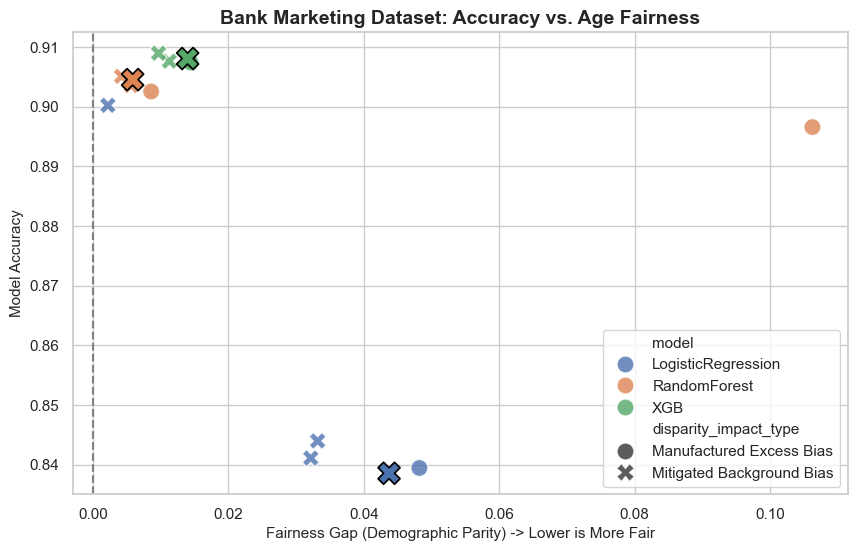

In [22]:
# === CELL 11: BANK MARKETING VISUALIZATION ===
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Separate Baselines and Mitigations
baselines = bank_all_mitigations[bank_all_mitigations['miti_method'] == 'Baseline']
mitigations = bank_all_mitigations[bank_all_mitigations['miti_method'] != 'Baseline']

# Plot Mitigations
sns.scatterplot(
    data=mitigations, 
    x='Demographic Parity', 
    y='accuracy', 
    hue='model', 
    style='disparity_impact_type',
    s=150, 
    alpha=0.8
)

# Plot Baselines with a distinct star marker
sns.scatterplot(
    data=baselines, 
    x='Demographic Parity', 
    y='accuracy', 
    hue='model', 
    marker='X', 
    s=250, 
    edgecolor='black', 
    legend=False
)

# Draw arrows showing the shift for the main highlights
plt.title("Bank Marketing Dataset: Accuracy vs. Age Fairness", fontsize=14, fontweight='bold')
plt.xlabel("Fairness Gap (Demographic Parity) -> Lower is More Fair", fontsize=11)
plt.ylabel("Model Accuracy", fontsize=11)
plt.axvline(x=0.0, color='gray', linestyle='--')

print("💡 TIP: The 'X' marks represent the untouched Baselines. Watch how ThresholdOptimizer shifts them!")
plt.show()